In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(r"C:\Users\lenovo\Downloads\Customer Churn Detection.csv")

In [3]:
df.head()

,Customer_ID,Age,Gender,Location,Subscription,Tenure_Months,Monthly_Charges,Usage_Hours,Support_Calls,Satisfaction,Payment_Method,Churn
0,1001,24.0,Female,Kochi,Basic,44,756.68,36.87,2,5.0,Debit Card,No
1,1002,51.0,Female,Kannur,Basic,33,812.62,26.44,2,1.0,UPI,No
2,1003,47.0,Male,Thrissur,Basic,9,2305.84,11.85,4,5.0,UPI,Yes
3,1004,38.0,Female,Kochi,Standard,7,2360.78,15.04,5,10.0,Debit Card,No
4,1005,38.0,Male,Kochi,Standard,42,1364.71,14.30,1,4.0,Credit Card,Yes


In [4]:
df.tail()

,Customer_ID,Age,Gender,Location,Subscription,Tenure_Months,Monthly_Charges,Usage_Hours,Support_Calls,Satisfaction,Payment_Method,Churn
300,1013,50.0,Male,Kannur,Basic,44,857.11,49.06,3,6.0,Net Banking,No
301,1058,27.0,Female,Thrissur,Basic,31,1780.75,4.00,3,5.0,Cash,Yes
302,1144,37.0,Male,Trivandrum,Basic,6,1754.81,28.15,1,1.0,Credit Card,No
303,1222,39.0,Male,Trivandrum,Basic,2,1242.38,33.04,1,7.0,UPI,No
304,1277,39.0,Male,Kochi,Premium,41,1650.92,28.73,0,2.0,Credit Card,No


In [5]:
df.shape

(305, 12)

In [6]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Location', 'Subscription',
       'Tenure_Months', 'Monthly_Charges', 'Usage_Hours', 'Support_Calls',
       'Satisfaction', 'Payment_Method', 'Churn'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      305 non-null    int64  
 1   Age              295 non-null    float64
 2   Gender           305 non-null    str    
 3   Location         305 non-null    str    
 4   Subscription     297 non-null    str    
 5   Tenure_Months    305 non-null    int64  
 6   Monthly_Charges  305 non-null    float64
 7   Usage_Hours      305 non-null    float64
 8   Support_Calls    305 non-null    int64  
 9   Satisfaction     295 non-null    float64
 10  Payment_Method   305 non-null    str    
 11  Churn            305 non-null    str    
dtypes: float64(4), int64(3), str(5)
memory usage: 37.1 KB


In [8]:
df.isnull().sum()

Customer_ID         0
Age                10
Gender              0
Location            0
Subscription        8
Tenure_Months       0
Monthly_Charges     0
Usage_Hours         0
Support_Calls       0
Satisfaction       10
Payment_Method      0
Churn               0
dtype: int64

In [9]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [10]:
df["Satisfaction"] =df["Satisfaction"].fillna(df["Satisfaction"].median())

In [11]:
df["Subscription"] = df["Subscription"].fillna(df["Subscription"].mode()[0])

In [12]:
df.duplicated().sum()

np.int64(5)

In [13]:
df = df.drop_duplicates()

In [14]:
df.shape

(300, 12)

In [15]:
df.shape[0]                    

300

In [16]:
df["Churn"].value_counts()     

Churn
No     224
Yes     76
Name: count, dtype: int64

In [17]:
churn_rate = (df["Churn"] == "Yes").mean() * 100

In [18]:
print("Churn Rate:",
round(churn_rate, 2), "%")

Churn Rate: 25.33 %


In [19]:
df["Monthly_Charges"].mean()

np.float64(1511.7915)

In [20]:
df["Monthly_Charges"].median()

np.float64(1480.805)

In [21]:
df["Monthly_Charges"].std()

np.float64(525.6917122323526)

In [22]:
df.describe()

,Customer_ID,Age,Tenure_Months,Monthly_Charges,Usage_Hours,Support_Calls,Satisfaction
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,1150.500000,40.553955,24.393333,1511.791500,27.391033,2.596667,5.393333
std,86.746758,10.658837,13.885291,525.691712,11.241656,1.592412,2.766006
min,1001.000000,21.000000,1.000000,499.000000,4.000000,0.000000,1.000000
25%,1075.750000,32.000000,12.750000,1145.512500,20.005000,1.000000,3.000000
50%,1150.500000,40.518644,23.000000,1480.805000,27.360000,2.000000,5.000000
75%,1225.250000,49.000000,37.000000,1835.142500,35.240000,3.000000,8.000000
max,1300.000000,60.000000,48.000000,2832.220000,58.000000,8.000000,10.000000


In [23]:
pd.crosstab(df["Subscription"], df["Churn"])


Churn,No,Yes
Subscription,,
Basic,89,38
Premium,48,19
Standard,87,19


In [24]:
pd.crosstab(df["Location"], df["Churn"])

Churn,No,Yes
Location,,
Calicut,51,17
Kannur,35,9
Kochi,57,15
Thrissur,31,22
Trivandrum,50,13


In [25]:
pd.crosstab(df["Location"], df["Churn"])

Churn,No,Yes
Location,,
Calicut,51,17
Kannur,35,9
Kochi,57,15
Thrissur,31,22
Trivandrum,50,13


In [26]:
df.groupby("Churn")["Support_Calls"].mean()

Churn
No     2.500000
Yes    2.881579
Name: Support_Calls, dtype: float64

In [27]:
df.groupby("Churn")["Satisfaction"].mean()

Churn
No     5.531250
Yes    4.986842
Name: Satisfaction, dtype: float64

In [28]:
df.groupby("Churn")["Usage_Hours"].mean()

Churn
No     28.405759
Yes    24.400263
Name: Usage_Hours, dtype: float64

In [29]:
df.groupby("Churn")["Tenure_Months"].mean()

Churn
No     24.857143
Yes    23.026316
Name: Tenure_Months, dtype: float64

In [30]:
corr = df[["Age","Tenure_Months","Monthly_Charges","Usage_Hours","Support_Calls","Satisfaction"]].corr()
corr

,Age,Tenure_Months,Monthly_Charges,Usage_Hours,Support_Calls,Satisfaction
Age,1.000000,-0.013990,-0.001727,0.061376,-0.006497,0.023584
Tenure_Months,-0.013990,1.000000,-0.139506,0.016464,0.054240,0.022953
Monthly_Charges,-0.001727,-0.139506,1.000000,0.093713,0.046816,-0.045295
Usage_Hours,0.061376,0.016464,0.093713,1.000000,0.001006,-0.005592
Support_Calls,-0.006497,0.054240,0.046816,0.001006,1.000000,0.116625
Satisfaction,0.023584,0.022953,-0.045295,-0.005592,0.116625,1.000000


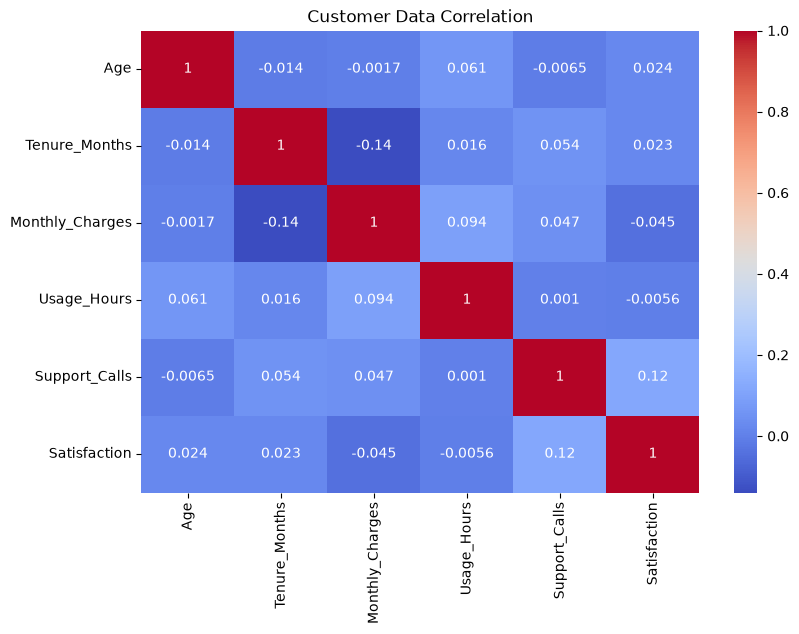

In [31]:
plt.figure(figsize=(9, 6))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Customer Data Correlation")
plt.show()

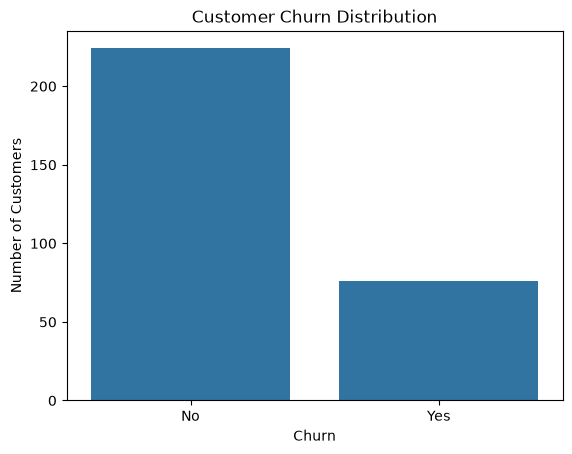

In [32]:
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.ylabel("Number of Customers")
plt.show()

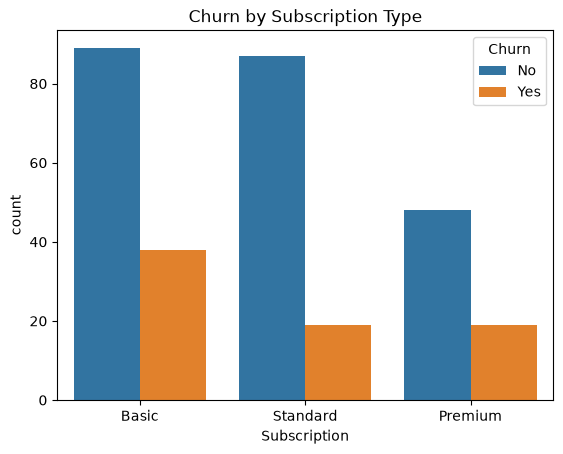

In [33]:
sns.countplot(data=df,x="Subscription",hue="Churn")
plt.title("Churn by Subscription Type")
plt.show()

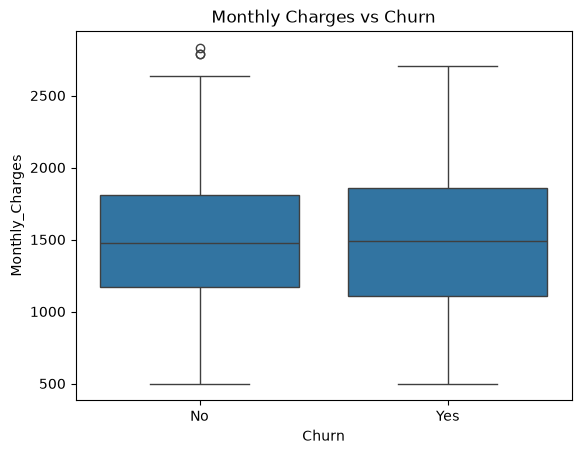

In [34]:
sns.boxplot(data=df,x="Churn",y="Monthly_Charges")
plt.title("Monthly Charges vs Churn")
plt.show()

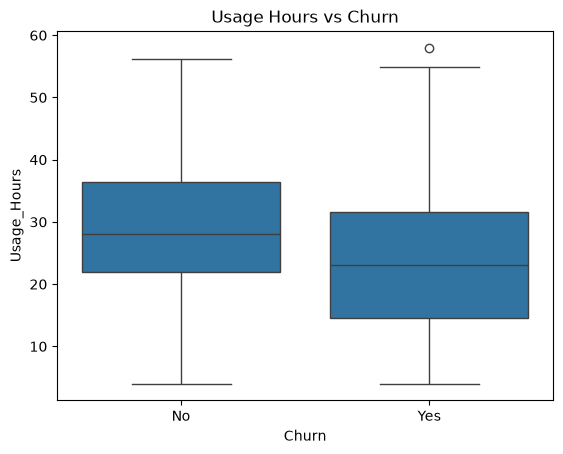

In [35]:
sns.boxplot(data=df,x="Churn",y="Usage_Hours")
plt.title("Usage Hours vs Churn")
plt.show()